#Task 1: Exploratory Data Analysis (EDA):

1. Load the dataset and perform basic data exploration.

2. Examine the distribution of features using histograms, box plots, or density plots.

3. Investigate correlations between features to understand relationships within the data.

Task 2: Dimensionality Reduction with PCA:

1. Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

2. Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

3. Transform the original dataset into the principal components.

Task 3: Clustering with Original Data:

1. Apply a clustering algorithm (e.g., K-means) to the original dataset.

2. Visualize the clustering results using appropriate plots.

3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

Task 4: Clustering with PCA Data:

1. Apply the same clustering algorithm to the PCA-transformed dataset.

2. Visualize the clustering results obtained from PCA-transformed data.

3. Compare the clustering results from PCA-transformed data with those from the original dataset.

Task 5: Comparison and Analysis:

1. Compare the clustering results obtained from the original dataset and PCA-transformed data.

2. Discuss any similarities or differences observed in the clustering results.

3. Reflect on the impact of dimensionality reduction on clustering performance.

4. Analyze the trade-offs between using PCA and clustering directly on the original dataset.

Task 6: Conclusion and Insights


1. Summarize the key findings and insights from the assignment.

2. Discuss the practical implications of using PCA and clustering in data analysis.

3. Provide recommendations for when to use each technique based on the analysis conducted.

First 5 rows:
    Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 col

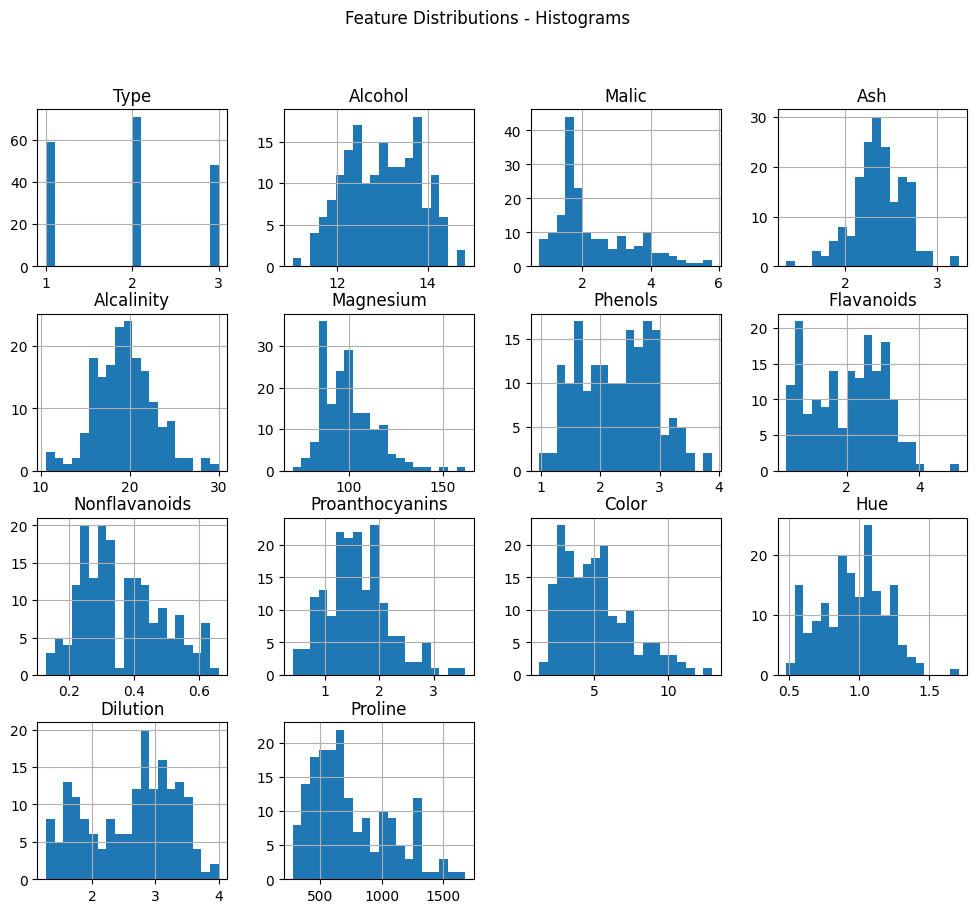

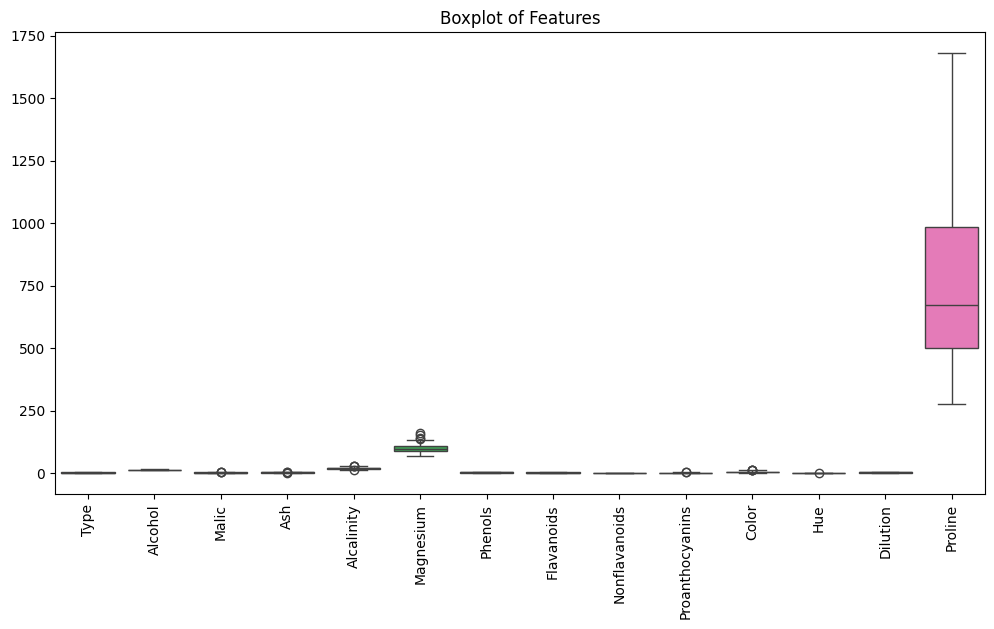

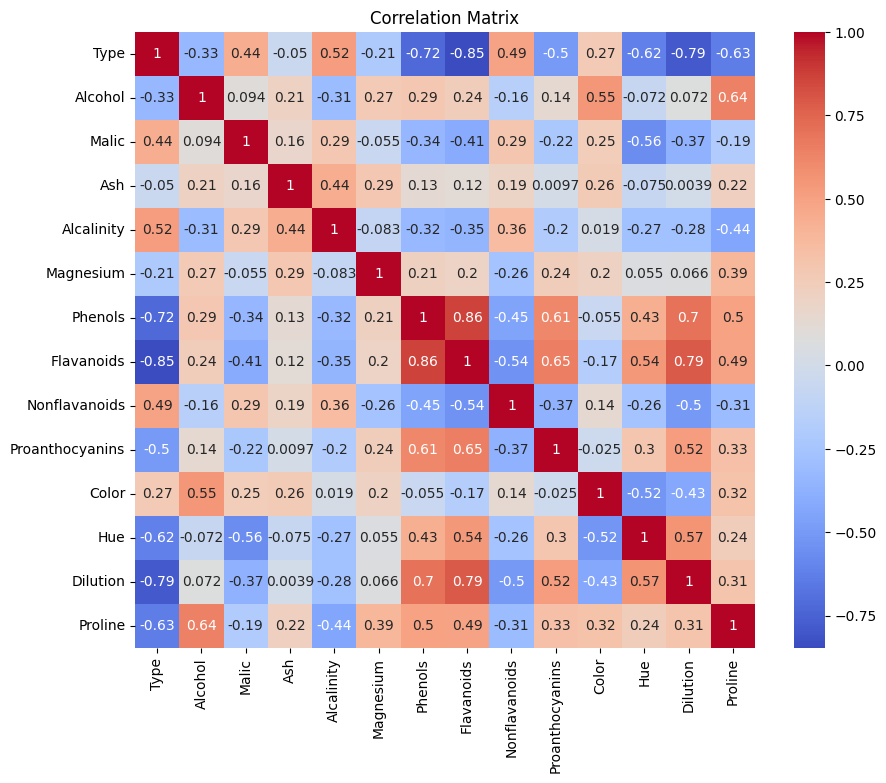

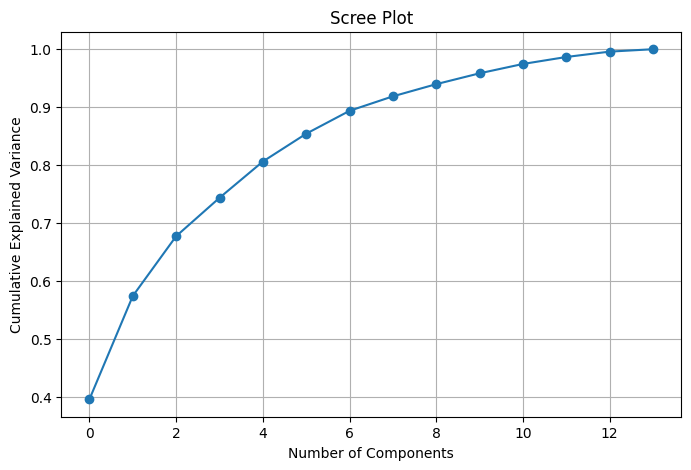

Optimal number of components (95% variance): 10


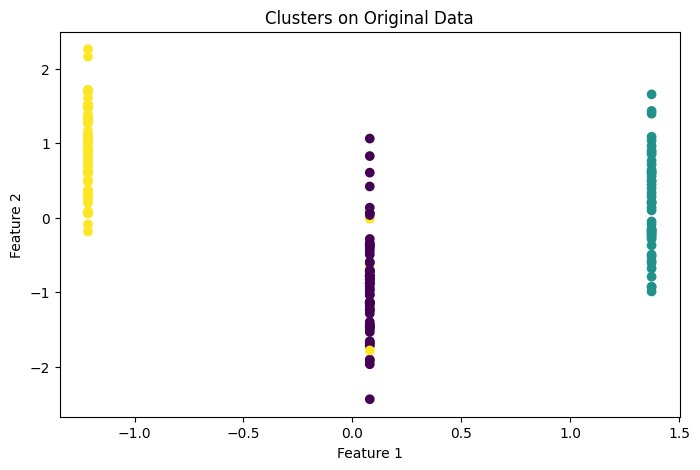

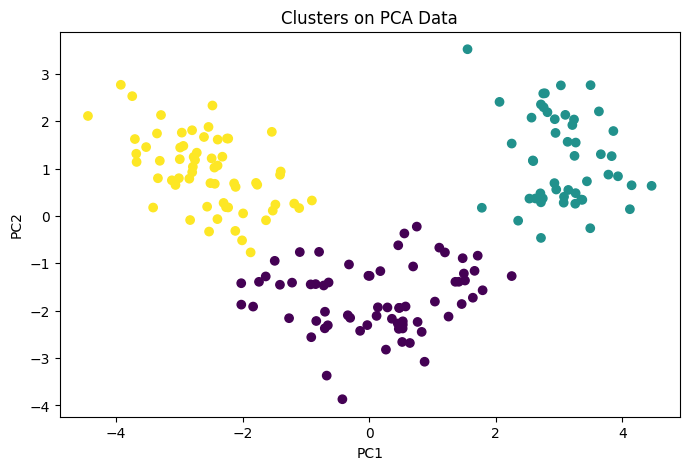


Clustering Performance Comparison:

          Method  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.306484              1.315708
1       PCA Data          0.322921              1.257845

Interpretation:
✔ PCA improved clustering (higher Silhouette Score).
✔ PCA produced more compact clusters (lower DB Index).

Total variance explained by selected PCA components: 0.9584270259947617

Conclusion:
- PCA reduced dimensionality while retaining most of the variance.
- Clustering was performed on both original and PCA-transformed data.
- Performance was compared using Silhouette Score and Davies–Bouldin Index.
- PCA helps remove noise and correlated features, which can improve clustering.
- However, PCA reduces interpretability of original features.


In [1]:
# =========================================================
# COMPLETE EDA + PCA + CLUSTERING PIPELINE (WINE DATASET)
# =========================================================

# 🔹 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# =========================================================
# Task 1: Load Dataset & EDA
# =========================================================

# Load dataset
df = pd.read_csv("/content/wine.csv")

# Keep only numerical columns
df = df.select_dtypes(include=[np.number])

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Histograms
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions - Histograms")
plt.show()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================================================
# Task 2: Standardization + PCA
# =========================================================

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# PCA (all components for scree plot)
pca = PCA()
pca_full = pca.fit_transform(scaled_data)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

# Select number of components (95% variance)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1
print("Optimal number of components (95% variance):", n_components)

# Apply PCA with optimal components
pca = PCA(n_components=n_components)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data)

# =========================================================
# Task 3: Clustering on Original Data
# =========================================================

k = 3  # Wine dataset has 3 classes

kmeans_orig = KMeans(n_clusters=k, random_state=42)
orig_clusters = kmeans_orig.fit_predict(scaled_data)

# Evaluation
sil_orig = silhouette_score(scaled_data, orig_clusters)
db_orig = davies_bouldin_score(scaled_data, orig_clusters)

# Visualization (first 2 features)
plt.figure(figsize=(8,5))
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=orig_clusters, cmap='viridis')
plt.title("Clusters on Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# =========================================================
# Task 4: Clustering on PCA Data
# =========================================================

kmeans_pca = KMeans(n_clusters=k, random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_data)

# Evaluation
sil_pca = silhouette_score(pca_data, pca_clusters)
db_pca = davies_bouldin_score(pca_data, pca_clusters)

# Visualization (first 2 principal components)
plt.figure(figsize=(8,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=pca_clusters, cmap='viridis')
plt.title("Clusters on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# =========================================================
# Task 5: Comparison & Analysis
# =========================================================

comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [sil_orig, sil_pca],
    "Davies-Bouldin Index": [db_orig, db_pca]
})

print("\nClustering Performance Comparison:\n")
print(comparison)

print("\nInterpretation:")

if sil_pca > sil_orig:
    print("✔ PCA improved clustering (higher Silhouette Score).")
else:
    print("✘ PCA did not significantly improve Silhouette Score.")

if db_pca < db_orig:
    print("✔ PCA produced more compact clusters (lower DB Index).")
else:
    print("✘ PCA did not significantly improve DB Index.")

print("\nTotal variance explained by selected PCA components:",
      np.sum(pca.explained_variance_ratio_))

# =========================================================
# Task 6: Conclusion (Auto Insights)
# =========================================================

print("\nConclusion:")
print("- PCA reduced dimensionality while retaining most of the variance.")
print("- Clustering was performed on both original and PCA-transformed data.")
print("- Performance was compared using Silhouette Score and Davies–Bouldin Index.")
print("- PCA helps remove noise and correlated features, which can improve clustering.")
print("- However, PCA reduces interpretability of original features.")